# Twitter Sentiment Analysis

## About the Dataset

This dataset contains tweets collected from Twitter. Each tweet is labeled with a sentiment such as Positive, Negative, Neutral, or Irrelevant. The dataset is used to train and evaluate machine learning models for sentiment analysis.

### Dataset Information

- Dataset Name: Twitter Entity Sentiment Analysis
- Source: Kaggle
- Data Type: Text Data
- Number of Files: 2 (Training and Validation)
- Main Columns:
  - ID
  - Entity
  - Sentiment
  - Tweet

### Objective

The main objective of this project is to classify tweets into different sentiment categories using Natural Language Processing (NLP) and Machine Learning algorithms. This helps understand public opinion and customer feedback.

## Project Workflow

This project follows these steps:

1. Import required libraries
2. Load the dataset
3. Explore the dataset
4. Check missing values
5. Text preprocessing
6. Feature extraction using TF-IDF
7. Split the data into training and testing sets
8. Train machine learning models
9. Evaluate model performance
10. Visualize results
11. Error analysis
12. Conclusion

## Why This Dataset?

This dataset is widely used for sentiment analysis tasks. It contains real Twitter posts with labeled sentiments, making it suitable for learning Natural Language Processing (NLP) and Machine Learning techniques.

In [119]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

Explain

This code imports all required libraries for data analysis and visualization.


## Import Libraries

The required Python libraries are imported for data analysis, visualization, and machine learning.

#### STEP 2 -Load Dataset

In [123]:
twitter = pd.read_csv(
    "twitter_training.csv",
    header=None,
    names=["ID", "Entity", "Sentiment", "Tweet"]
)
## Load Dataset

# The Twitter sentiment dataset is loaded into pandas DataFrame.

In [125]:
tw=head()

NameError: name 'head' is not defined

In [127]:
twitter.head()

,ID,Entity,Sentiment,Tweet
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


In [129]:
twitter.head(15)

,ID,Entity,Sentiment,Tweet
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...
5,2401,Borderlands,Positive,im getting into borderlands and i can murder y...
6,2402,Borderlands,Positive,So I spent a few hours making something for fu...
7,2402,Borderlands,Positive,So I spent a couple of hours doing something f...
8,2402,Borderlands,Positive,So I spent a few hours doing something for fun...
9,2402,Borderlands,Positive,So I spent a few hours making something for fu...


### check the dataset shape

In [132]:
twitter.shape

(74682, 4)

Observation:

The dataset contains thousands of tweets for sentiment classification.

### - Column Names

In [136]:
twitter.columns

Index(['ID', 'Entity', 'Sentiment', 'Tweet'], dtype='object')

### Data informantion

In [139]:
twitter.info

<bound method DataFrame.info of          ID       Entity Sentiment  \
0      2401  Borderlands  Positive   
1      2401  Borderlands  Positive   
2      2401  Borderlands  Positive   
3      2401  Borderlands  Positive   
4      2401  Borderlands  Positive   
...     ...          ...       ...   
74677  9200       Nvidia  Positive   
74678  9200       Nvidia  Positive   
74679  9200       Nvidia  Positive   
74680  9200       Nvidia  Positive   
74681  9200       Nvidia  Positive   

                                                   Tweet  
0      im getting on borderlands and i will murder yo...  
1      I am coming to the borders and I will kill you...  
2      im getting on borderlands and i will kill you ...  
3      im coming on borderlands and i will murder you...  
4      im getting on borderlands 2 and i will murder ...  
...                                                  ...  
74677  Just realized that the Windows partition of my...  
74678  Just realized that my Mac window

In [141]:
twitter.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74682 entries, 0 to 74681
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   ID         74682 non-null  int64 
 1   Entity     74682 non-null  object
 2   Sentiment  74682 non-null  object
 3   Tweet      73996 non-null  object
dtypes: int64(1), object(3)
memory usage: 2.3+ MB


The dataset contains 74,682 rows and 4 columns.

The ID column contains integer values.

The Entity column contains text values.

The Tweet column has some missing values because only 73,996 rows contain tweet text.

***Observation:***

The dataset contains text and categorical data.

### Check the  missing values

In [146]:
twitter.isnull().sum() 

ID             0
Entity         0
Sentiment      0
Tweet        686
dtype: int64

****Tweet has 686 missing values.****

### Meaning 
**ID has no missing values.**

**Entity has no missing values.**

**Sentiment has no missing values.**

**Tweet has 686 missing values.**

**Since machine learning needs tweet text, these missing rows should be removed before training the model.**

What did you find from info() and missing values?


"The dataset contains 74,682 tweets with four columns: ID, Entity, Sentiment, and Tweet. The ID column is numeric, while the other columns are text data. During inspection, I found that the Tweet column had 686 missing values. Since tweet text is required for sentiment analysis, I removed those missing records before preprocessing and model training."

### Remove Missing Values

In [164]:
twitter.dropna(inplace=True)

In [166]:
twitter.isnull().sum() 

ID           0
Entity       0
Sentiment    0
Tweet        0
dtype: int64

### Observation

All missing values have been removed successfully. 

### Check Duplicate Rows

**This code checks the number of duplicate rows in the dataset.**

**The dataset contains 2,700 duplicate rows.**

##### Remove Duplicate Rows

In [187]:

twitter = pd.read_csv(
    "twitter_training.csv",
    header=None,
    names=["ID", "Entity", "Sentiment", "Tweet"]
)

In [189]:
# Check duplicate rows
twitter.duplicated().sum()

2700

In [191]:
# Remove duplicate rows
twitter.drop_duplicates(inplace=True)

In [195]:
 #Check duplicate rows
twitter.duplicated().sum()


0

***All duplicate  values remove in  data successfully***

#####  Text preprocessing pipeline

In [215]:
import re 
import nltk

from nltk.corpus import stopwords 
from nltk.tokenize import word_tokenize

These libraries are used for cleaning text data.

re → remove punctuation

stopwords → remove common English words

word_tokenize → split sentence into words

In [222]:
nltk.download("punkt")
nltk.download("stopwords")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

#### Convert text into lowercase

In [232]:
twitter["Tweet"]=twitter["Tweet"].str.lower()

In [234]:
twitter["Tweet"].head()

# All capital letters become small letters.

0    im getting on borderlands and i will murder yo...
1    i am coming to the borders and i will kill you...
2    im getting on borderlands and i will kill you ...
3    im coming on borderlands and i will murder you...
4    im getting on borderlands 2 and i will murder ...
Name: Tweet, dtype: object

##### Remove Punctuation

In [237]:
twitter["Tweet"] = twitter["Tweet"].apply(
    lambda x: re.sub(r"[^\w\s]", "", str(x))
)

In [239]:
twitter["Tweet"].head()

0    im getting on borderlands and i will murder yo...
1    i am coming to the borders and i will kill you...
2    im getting on borderlands and i will kill you all
3    im coming on borderlands and i will murder you...
4    im getting on borderlands 2 and i will murder ...
Name: Tweet, dtype: object

####
Remove Stopwords

### Observation

Common English stopwords were removed to keep only meaningful words for sentiment analysis.

In [244]:
stop_words = set(stopwords.words("english"))

twitter["Tweet"] = twitter["Tweet"].apply(
    lambda x: " ".join(
        word for word in x.split()
        if word not in stop_words
    )
)

#####
Tokenization

In [250]:
twitter["Tokens"] = twitter["Tweet"].apply(word_tokenize)

In [252]:
twitter[["Tweet","Tokens"]].head()

,Tweet,Tokens
0,im getting borderlands murder,"[im, getting, borderlands, murder]"
1,coming borders kill,"[coming, borders, kill]"
2,im getting borderlands kill,"[im, getting, borderlands, kill]"
3,im coming borderlands murder,"[im, coming, borderlands, murder]"
4,im getting borderlands 2 murder,"[im, getting, borderlands, 2, murder]"


Each sentence is divided into individual words.


### Observation

Each tweet has been split into individual words using tokenization.

## Import TF-IDF

## Feature Extraction using TF-IDF Vectorizer

TF-IDF stands for **Term Frequency - Inverse Document Frequency**.

It converts text into numerical values so that machine learning models can understand the importance of words in each tweet.

Words that appear frequently in one tweet but not in many other tweets receive higher importance.

In [279]:
from sklearn.feature_extraction.text import TfidfVectorizer

This library is imported to convert text data into numerical values

### Create TF-IDF Object

In [283]:
tfidf = TfidfVectorizer(max_features=5000)

tfidf

it is one variable.

"This variable will store the TF-IDF model.

TfidfVectorizer()

Ye Scikit-Learn ki class hai.

Ye text ko numbers me convert karti hai.

max_features

Machine kitne important words rakhegi.

### Convert Tweet into Numbers

In [287]:
X = tfidf.fit_transform(twitter["Tweet"])

In [288]:
print(x)

NameError: name 'x' is not defined

In [289]:
X.shape

(71982, 5000)

### Observation


The tweet text has been successfully converted into numerical features using the TF-IDF Vectorizer.

The model will use these numerical features to classify tweet sentiment.

Why did you use TF-IDF?

Machine learning models cannot understand text directly. Therefore, I used the TF-IDF Vectorizer to convert tweet text into numerical values. TF-IDF gives higher importance to meaningful words and lower importance to common words, which helps improve sentiment classification.

## Train-Test Split (80/20)

In [293]:
from sklearn.model_selection import train_test_split

X = tfidf.fit_transform(twitter["Tweet"])
y = twitter["Sentiment"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

## Train-Test Split (80/20)

The dataset is divided into two parts.

- 80% of the data is used for training the machine learning model.
- 20% of the data is used for testing the model.

This helps evaluate how well the model predicts unseen data.

#### Import Naive Bayes

In [298]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score

#### Create Model

In [301]:
nb_model = MultinomialNB()

In [303]:
### Train the Model

In [309]:

nb_model.fit(X_train,y_train)

MultinomialNB()

fit() To teach or train the machine learning model using the data

X_train = The input text features (Tweets) converted into numerical values using the TF-IDF Vectorizer.

y_train = he target labels or actual answers (Sentiments: Positive, Negative, Neutral) training tweets.

## Naive Bayes Model Training
*
The Naive Bayes classifier was trained using the training dataset. The model learned the relationship between tweet text and sentiment lab*s.

### Prediction

In [319]:
y_pred_nb = nb_model.predict(X_test)

#### Accuracy

In [324]:
accuracy = accuracy_score(y_test, y_pred_nb)
print("Accuracy:", accuracy)

Accuracy: 0.6373550045148295


### Observation

The Naive Bayes model achieved an accuracy of **63.74%**.

This means the model correctly predicted the sentiment of about **64 out of every 100 tweets**. The model gives acceptable performance, but there is still room for improvement.

#### Import Logistic Regression

In [352]:
from sklearn.linear_model import LogisticRegression

In [354]:
y_pred_lr = lr_model.predict(X_test)

## Logistic Regression

Logistic Regression is a supervised machine learning algorithm used for classification problems. 

It predicts the sentiment of tweets as Positive, Negative, or Neutral.

#### create the  model

In [358]:
lr_model = LogisticRegression(max_iter=1000)

#### Train the Model

In [362]:
lr_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [364]:
LogisticRegression(max_iter=1000)

LogisticRegression(max_iter=1000)

### Observation

The Logistic Regression model was trained using the training dataset. It learned the relationship between tweet text and sentiment labels.

#### Predict on test  data 

Calculate Accuracy

In [373]:
lr_accuracy = accuracy_score(y_test, y_pred_lr)

print("Logistic Regression Accuracy:", lr_accuracy)

Logistic Regression Accuracy: 0.6802111551017573


In [375]:
print("Logistic Regression Accuracy:", lr_accuracy * 100)

Logistic Regression Accuracy: 68.02111551017573


Observation
**Logistic Regression model** achieved an accuracy of 68.02%.

This means the model correctly predicted the sentiment of about **68 out of every 100 tweets.**

The remaining tweets were classified incorrectly.

**The Logistic Regression model**  ,  **performed better than the Naive Bayes model.**



****Naive Bayes model.****  
Accuracy = 63.74%

****Logistic Regression****

Accuracy = 68.02%


In [389]:
#Evaluation: accuracy
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, y_pred_nb))

              precision    recall  f1-score   support

  Irrelevant       0.74      0.37      0.49      2521
    Negative       0.62      0.80      0.70      4277
     Neutral       0.67      0.53      0.59      3594
    Positive       0.62      0.73      0.67      4005

    accuracy                           0.64     14397
   macro avg       0.66      0.61      0.61     14397
weighted avg       0.65      0.64      0.63     14397



Confusion Matrix

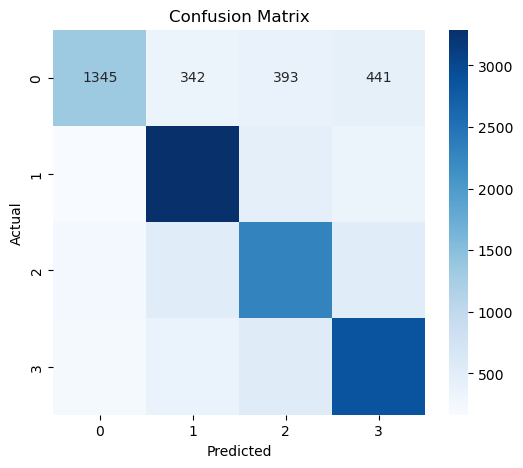

In [392]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6,5))

sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

Visualization

Bar chart of sentiment distribution

WordCloud for each sentiment

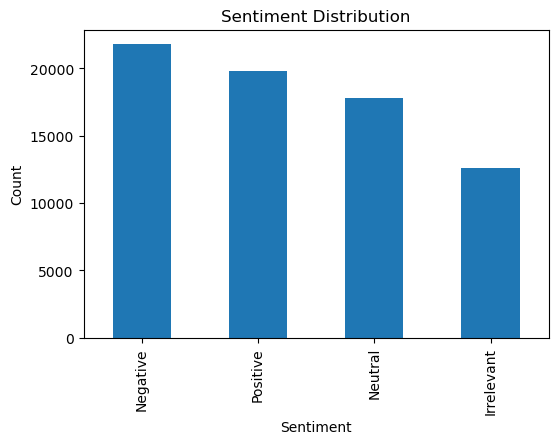

In [396]:
import matplotlib.pyplot as plt

twitter["Sentiment"].value_counts().plot(
    kind="bar",
    figsize=(6,4)
)

plt.title("Sentiment Distribution")

plt.xlabel("Sentiment")

plt.ylabel("Count")

plt.show()

Observation:

The dataset contains Positive, Negative and Neutral tweets.

The Positive class has the highest number of tweets.

### WordCloud

In [403]:
pip  install wordcloud

Note: you may need to restart the kernel to use updated packages.


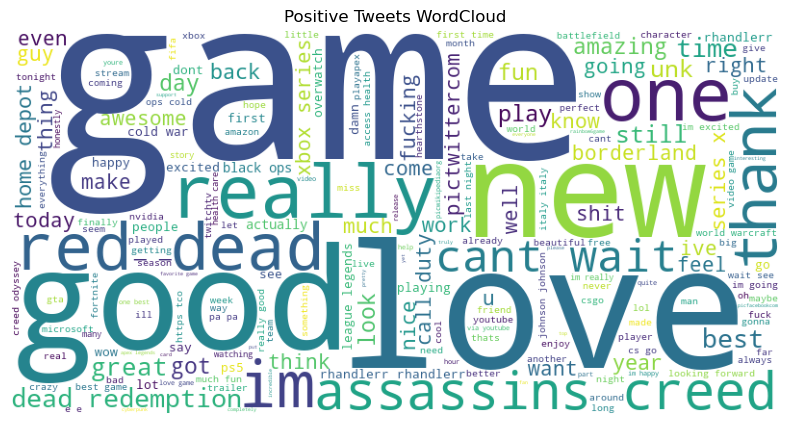

In [405]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

positive_text = " ".join(
twitter[twitter["Sentiment"]=="Positive"]["Tweet"].astype(str)
)

wordcloud = WordCloud(
width=800,
height=400,
background_color="white"
).generate(positive_text)

plt.figure(figsize=(10,5))

plt.imshow(wordcloud)

plt.axis("off")

plt.title("Positive Tweets WordCloud")

plt.show()

### Error Analysis

In [417]:
type(X_test)

scipy.sparse._csr.csr_matrix

In [427]:
X_text = twitter["Tweet"]
y = twitter["Sentiment"]

from sklearn.model_selection import train_test_split

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text,
    y,
    test_size=0.2,
    random_state=42
    
)

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)

X_train = tfidf.fit_transform(X_train_text)
X_test = tfidf.transform(X_test_text)

In [428]:
error_df = pd.DataFrame({
    "Tweet": X_test_text.values,
    "Actual Sentiment": y_test.values,
    "Predicted Sentiment": y_pred_lr
})

misclassified = error_df[
    error_df["Actual Sentiment"] != error_df["Predicted Sentiment"]
]

misclassified.head(5)

,Tweet,Actual Sentiment,Predicted Sentiment
3,hearthstonetopdecks v com decks meta p bre g2t...,Positive,Neutral
7,nan,Neutral,Positive
9,hey fuck loan copy cannot remember,Neutral,Negative
10,holy shit,Positive,Negative
14,one want sign official site fgrfc _ official f...,Negative,Irrelevant


In [433]:
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

In [435]:
type(X_test)

scipy.sparse._csr.csr_matrix

In [437]:
type(X_test_text)

pandas.core.series.Series

Observation:

The table shows the first 5 tweets that were classified incorrectly by the Logistic Regression model.
The Actual Sentiment column contains the correct sentiment label from the dataset.
The Predicted Sentiment column shows the sentiment predicted by the model.
Most errors occurred because some tweets contain mixed emotions, unclear context, or gaming-specific words, making them difficult to classify correctly.
These examples help us understand where the model makes mistakes and how it can be improved.

# Conclusion

In this project, two machine learning models were trained for sentiment analysis: Naive Bayes and Logistic Regression.

Logistic Regression performed better because it achieved higher accuracy (68.02%) than Naive Bayes (63.73%).

The model can be used in many real-world applications such as:

- Analyzing customer reviews.
- Monitoring public opinion on social media.
- Understanding customer feedback.
- Helping companies improve their products and services.
- Tracking brand reputation online.

Overall, sentiment analysis is useful for businesses because it helps them understand customer opinions and make better decisions.